[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfelipevasquez/Forecasting-electricity-production-Kaggle/blob/main/04_Model_XGBoost.ipynb)

# Extreme Gradient Boosting

This model aims to achieve the best performance by using the [XGBoost](https://en.wikipedia.org/wiki/XGBoost)  model to address the problem of predicting photovoltaic power output based on meteorological data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import  mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import learning_curve



In [ ]:
# Read the train dataset of competition

Dataset_original_train = pd.read_csv("https://raw.githubusercontent.com/jfelipevasquez/Forecasting-electricity-production-Kaggle/refs/heads/main/dataset/train.csv").set_index('ID')
Dataset_original_train.head()

,start,kw,capacity_clipped,time_hourly,S_d,airmass,altitude,azimuth,irradiation,fold_cos,...,rad_lw_mean,precip_total_mean,cloud_total_mean,temp_total_mean,cloud_high_mean,rad_global_mean,cloud_low_mean,radNetS_lw_mean,cloud_mid_mean,radNetS_sw_mean
ID,,,,,,,,,,,,,,,,,,,,,
0,2019-01-02 01:00:00,0.0,468.0,2019-01-02 01:00:00.000000,0.0,-1.153310,-60.119844,39.300368,0.0,-0.0,...,28559320.0,NaN,87.436623,2.016479,0.735016,3692351.75,0.517294,-4335172.0,0.510855,2910957.0
1,2019-01-02 01:15:00,0.0,468.0,2019-01-02 01:00:00.000000,0.0,-1.173570,-58.440884,45.209051,0.0,-0.0,...,28559320.0,NaN,87.436623,2.016479,0.735016,3692351.75,0.517294,-4335172.0,0.510855,2910957.0
2,2019-01-02 01:45:00,0.0,468.0,2019-01-02 01:00:00.000000,0.0,-1.226941,-54.590829,55.621305,0.0,-0.0,...,28559320.0,NaN,87.436623,2.016479,0.735016,3692351.75,0.517294,-4335172.0,0.510855,2910957.0
3,2019-01-02 02:45:00,0.0,468.0,2019-01-02 02:00:00.000000,0.0,-1.398963,-45.628041,72.112254,0.0,-0.0,...,29545328.0,NaN,59.624264,2.035498,0.012997,3692351.75,0.329642,-4500247.5,0.370873,2910957.0
4,2019-01-02 03:00:00,0.0,468.0,2019-01-02 03:00:00.000000,0.0,-1.459987,-43.230706,75.591904,0.0,-0.0,...,30531976.0,NaN,63.706104,2.246095,0.000000,3692351.75,0.238952,-4664002.0,0.493319,2910957.0


## 1- Feature Engineering
Transforming and creating new features

In [ ]:
# Define a function to transform the data

def DataTransform(df):
  df = df.dropna(axis=1).copy()  # Eliminar todas las columnas vacías

  # Date and time features
  df['date'] = pd.to_datetime(df['start'])
  df['month'] = df['date'].dt.month
  df['day_year'] = df['date'].dt.dayofyear
  df['hour'] = df['date'].dt.hour

  # Delete unnecessary columns
  df = df.drop(columns=['start', 'day','capacity_clipped', 'time_hourly', 'sunrise', 'sunset'])

  # Create new cyclical time series variables
  df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
  df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
  df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
  df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
  df['day_year_sin'] = np.sin(2 * np.pi * df['day_year'] / 365)
  df['day_year_cos'] = np.cos(2 * np.pi * df['day_year'] / 365)
  df['azimuth_sin'] = np.sin(np.radians(df['azimuth']))
  df['azimuth_cos'] = np.cos(np.radians(df['azimuth']))

  df['is_day'] = (df['altitude'] > 0).astype(int)   # Create a variable to indicate whether it is a day

 # Create variables for Direct Normal Irradiance (DNI) and  Global Tilt Irradiance (GTI)
  df['DNI']=df['S_d']*df['fold_cos']
  df['GTI']=df['irradiation']*df['panel_cos']

  # Correcting negative radiation
  df['irradiation'] = df['irradiation'].clip(lower=0)


  return df

print(DataTransform(Dataset_original_train).columns)
DataTransform(Dataset_original_train).head()


Index(['kw', 'S_d', 'airmass', 'altitude', 'azimuth', 'irradiation',
       'fold_cos', 'panel_cos', 'date', 'month', 'day_year', 'hour',
       'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_year_sin',
       'day_year_cos', 'azimuth_sin', 'azimuth_cos', 'is_day', 'DNI', 'GTI'],
      dtype='object')


,kw,S_d,airmass,altitude,azimuth,irradiation,fold_cos,panel_cos,date,month,...,hour_cos,month_sin,month_cos,day_year_sin,day_year_cos,azimuth_sin,azimuth_cos,is_day,DNI,GTI
ID,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,-1.153310,-60.119844,39.300368,0.0,-0.0,-0.0,2019-01-02 01:00:00,1,...,0.965926,0.5,0.866025,0.034422,0.999407,0.633386,0.773836,0,-0.0,-0.0
1,0.0,0.0,-1.173570,-58.440884,45.209051,0.0,-0.0,-0.0,2019-01-02 01:15:00,1,...,0.965926,0.5,0.866025,0.034422,0.999407,0.709682,0.704522,0,-0.0,-0.0
2,0.0,0.0,-1.226941,-54.590829,55.621305,0.0,-0.0,-0.0,2019-01-02 01:45:00,1,...,0.965926,0.5,0.866025,0.034422,0.999407,0.825324,0.564660,0,-0.0,-0.0
3,0.0,0.0,-1.398963,-45.628041,72.112254,0.0,-0.0,-0.0,2019-01-02 02:45:00,1,...,0.866025,0.5,0.866025,0.034422,0.999407,0.951660,0.307153,0,-0.0,-0.0
4,0.0,0.0,-1.459987,-43.230706,75.591904,0.0,-0.0,-0.0,2019-01-02 03:00:00,1,...,0.707107,0.5,0.866025,0.034422,0.999407,0.968548,0.248827,0,-0.0,-0.0


## 2-  Split Train and Validation Data

In [ ]:
# Select X e y for model

df = DataTransform(Dataset_original_train)
y = df['kw']
X = df[[
    'S_d',
    'irradiation',
    'fold_cos',
    'panel_cos',
    'altitude',
    'azimuth',
    'azimuth_sin', 'azimuth_cos',
    'airmass',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'day_year_sin', 'day_year_cos',
    'DNI', 'GTI',
    'is_day',
    'month',
    'day_year',
    'hour'
]]

# Split in train and test with 20% for test
x_train, x_test, y_train, y_test= train_test_split(X,y, test_size=0.2)

## 3- Train Base Model

In [ ]:
XGBoost = XGBRegressor(
    n_estimators=800,
    learning_rate=0.04,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.7,
    n_jobs=-1
    )

XGBoost.fit(x_train, y_train)

y_pred = XGBoost.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('-- Base Model Metrics Results: --')
print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.3f}")


-- Base Model Metrics Results: --
MAE: 19.76
R2: 0.901


## 4- Feature Selection
In order to select the most representative features or those that contribute the most to the model, several techniques have been used

### 4.1 Feature Importance

`Feature importances`: shows how much a specific variable (column) helped the model make its predictions.

- The Rule of 1: If you sum up the importance of all features, the result is always exactly 1.0 (or 100%).

- High Values: The closer a number is to 1, the more important that variable is. The model relies heavily on it to predict the target.

- Zero or Near-Zero Values: If a feature has an importance close to 0, it means the model rarely used it to make decisions. You can safely delete these variables to make your model faster, lighter, and more efficient without losing accuracy.




In [ ]:
# Get the percentage of importance of each feature used in the previus train model
gain_feature = XGBoost.feature_importances_

# 2. Create a Series for visualization
feat_importances = pd.Series(gain_feature, name="Importance (%)", index=X.columns)*100
feat_importances.sort_values(ascending=False)

,Importance (%)
altitude,32.049301
S_d,14.420350
fold_cos,13.046651
irradiation,6.640740
GTI,4.819902
panel_cos,4.230515
month_cos,3.296692
DNI,3.234508
day_year,2.635761
day_year_sin,2.115091


### 4.2 Permutation Importance

*Permutation Importance* measures a variable's true value by testing how the model breaks without it.Instead of asking the model how it was built, this method takes a specific variable and shuffles its values randomly while keeping the other columns intact.

- High Values: If the model's error increases significantly after shuffling a variable, it means the model heavily depends on it.

- Zero or Negative Values: If the error stays the same or improves, the variable is useless or redundant.

 The results are measured in the exact same units as our metric (MAE). For example, if a feature has a score of +5.0, it means shuffling that variable makes the model average 5 more units of error.

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    XGBoost, x_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='neg_mean_absolute_error'
)

perm_imp = pd.DataFrame({
    'feature': x_test.columns,
    'Importance (MAE)': perm.importances_mean
}).sort_values('Importance (MAE)', ascending=False)

perm_imp['Importance (%)'] = perm_imp['Importance (MAE)'] / perm_imp['Importance (MAE)'].sum() * 100
perm_imp

,feature,Importance (MAE),Importance (%)
0,S_d,23.642292,24.058430
1,irradiation,18.771406,19.101809
13,day_year_sin,10.166727,10.345676
4,altitude,7.687657,7.822971
14,day_year_cos,6.689258,6.806999
3,panel_cos,6.637627,6.754459
19,day_year,5.550284,5.647977
16,GTI,5.425873,5.521376
2,fold_cos,3.854829,3.922679
7,azimuth_cos,2.755313,2.803810


### 4.3 Recursive Feature Elimination with Cross-Validation (RFECV)

RFECV is a robust and automated technique used to find the perfect number of variables for your model. Instead of guessing which features to keep, the algorithm follows a rigorous loop:

1. Train: It trains the model with all available features.

2. Rank: It calculates the importance of each feature.

3. Eliminate: It drops the least important variable (the weakest one).

4. Repeat: It repeats the process recursively until only one feature is left.

The Power of CV: By using Cross-Validation at every step, RFECV tracks how the MAE changes with different subset sizes.

The Final Output: It tells you the exact optimal number of features and the specific combination needed to get the absolute lowest error, preventing both overfitting and underfitting.

In [ ]:
from sklearn.feature_selection import RFECV

selector = RFECV(estimator=XGBoost, step=1, cv=5, scoring='neg_mean_absolute_error')
selector.fit(X, y)

# See which features it recommends
features_seleccionadas = X.columns[selector.support_]
print(f"Variables recomendadas ({len(features_seleccionadas)}): {list(features_seleccionadas)}")

# Create un DataFrame to see the ranking of features
ranking_df = pd.DataFrame({
    'Feature': X.columns,
    'Ranking': selector.ranking_
})

# Sort the ranking (1 level is the most important)
ranking_df = ranking_df.sort_values(by='Ranking')

print("Feature Ranking:")
ranking_df

Variables recomendadas (3): ['irradiation', 'fold_cos', 'altitude']
Feature Ranking:


,Feature,Ranking
1,irradiation,1
2,fold_cos,1
4,altitude,1
0,S_d,2
19,day_year,3
15,DNI,4
16,GTI,5
3,panel_cos,6
12,month_cos,7
18,month,8


### 4.4 Effect of Removing Features

After the three previous results, the variables that contribute least to the model are now known: `airmass`, `hour_sin`, `is_day`. The model will now be evaluated through cross-validation both when using all variables and when one of them is eliminated.

In [ ]:
# Shuffled the raws
from sklearn.utils import shuffle
X, y = shuffle(X, y, random_state=42)

# Define the feature ablation scenarios to evaluate using original X columns
experiments = {
    "All features": list(X.columns),
    "Removing airmass": [col for col in X.columns if col != 'airmass'],
    "Removing is_day": [col for col in X.columns if col != 'is_day'],
    "Removing hour_sin": [col for col in X.columns if col != 'hour_sin'],
    "Removing azimuth": [col for col in X.columns if col != 'azimuth'],
    "Removing month": [col for col in X.columns if col != 'month'],
    "Removing day_year": [col for col in X.columns if col != 'day_year'],
    "Removing hour": [col for col in X.columns if col != 'hour'],
}

results = []
print("Starting feature ablation experiments (this may take a few minutes)...")

#  Run the experiment loop
for exp_name, feature_list in experiments.items():

    # Filter the X matrix with the current experiment's columns
    X_temp = X[feature_list]

    # Calculate Cross-Validation using the original unshuffled data
    scores = cross_val_score(
        XGBoost,
        X_temp,
        y,
        scoring="neg_mean_absolute_error",
        cv=5,
        n_jobs=-1
    )

    mae_scores = -scores
    mae_mean = np.mean(mae_scores)
    mae_std = np.std(mae_scores)

    # Save the results into a list
    results.append({
        "Experiment": exp_name,
        "CV MAE Mean": round(mae_mean, 4),
        "Standard Deviation (±)": round(mae_std, 4),
        "Num Features": len(feature_list)
    })

# 4. Convert to DataFrame and display the clean final table
df_results = pd.DataFrame(results).sort_values(by='CV MAE Mean')
print("\n--- FINAL RESULTS TABLE ---")
display(df_results)

Starting feature ablation experiments (this may take a few minutes)...

--- FINAL RESULTS TABLE ---


,Experiment,CV MAE Mean,Standard Deviation (±),Num Features
2,Removing is_day,20.0819,0.6720,20
4,Removing azimuth,20.0872,0.6113,20
7,Removing hour,20.0957,0.6269,20
5,Removing month,20.1100,0.6374,20
1,Removing airmass,20.1128,0.6436,20
3,Removing hour_sin,20.1477,0.6553,20
0,All features,20.1582,0.5554,21
6,Removing day_year,20.6299,0.6314,20


In [ ]:
# 1. Define your 2 specific scenarios vs the baseline
experiments = {
    "All features": list(X.columns),

    "airmass, month, azimuth, hour_sin, is_day, hour": [
        col for col in X.columns if col not in ['airmass', 'month', 'azimuth', 'hour_sin', 'is_day', 'hour']
    ],
    "airmass,  is_day, hour_sin": [
        col for col in X.columns if col not in ['airmass',  'hour_sin', 'is_day']
    ],

    "airmass + azimuth + hour_sin": [
        col for col in X.columns if col not in ['airmass', 'azimuth', 'hour_sin']
    ]
}

results = []
print("Starting custom feature selection experiments...")

# 3. Run the experiment loop
for exp_name, feature_list in experiments.items():
    X_temp = X[feature_list]

    # Calculate Cross-Validation
    scores = cross_val_score(
        XGBoost,
        X_temp,
        y,
        scoring="neg_mean_absolute_error",
        cv=5,
        n_jobs=-1
    )

    mae_scores = -scores
    mae_mean = np.mean(mae_scores)
    mae_std = np.std(mae_scores)

    # Save the results into a list
    results.append({
        "Experiment": exp_name,
        "CV MAE Mean": round(mae_mean, 4),
        "Standard Deviation (±)": round(mae_std, 4),
        "Num Features": len(feature_list)
    })

# 4. Convert to DataFrame and display the clean final table
df_results = pd.DataFrame(results).sort_values(by='CV MAE Mean')
print("\n--- CUSTOM EXPERIMENTS RESULTS ---")
display(df_results)

Starting custom feature selection experiments...

--- CUSTOM EXPERIMENTS RESULTS ---


,Experiment,CV MAE Mean,Standard Deviation (±),Num Features
0,All features,20.1582,0.5554,21
2,"airmass, is_day, hour_sin",20.1921,0.6596,18
3,airmass + azimuth + hour_sin,20.2289,0.5821,18
1,"airmass, month, azimuth, hour_sin, is_day, hour",20.3350,0.5665,15


### 4.5 Feature Selection Conclusions

The features `airmass`, `month`, `azimuth`, `hour_sin`,`is_day`,  `hour` . These variables don't contribute much to the model; moreover, they reduce the MAE when removed. However, the effect is minimal or negligible. <br>

The final decision is drop `airmass` + `azimuth` + `hour_sin`

In [ ]:
df = DataTransform(Dataset_original_train)
features_selected = [ 'S_d', 'irradiation',  'fold_cos','panel_cos', 'altitude', 'azimuth_sin', 'azimuth_cos',  'hour_cos',   'month_sin', 'month_cos',
    'day_year_sin', 'day_year_cos',  'DNI', 'GTI',  'is_day',  'month',  'day_year',  'hour']

y = df['kw']
X = df[features_selected]

# Split in train and test with 20% for test
x_train, x_test, y_train, y_test= train_test_split(X,y, test_size=0.2)



## 5- Finding optimal hyperparameters

XGBoost Hyperparameter Overview

XGBoost performance strongly depends on the balance between model complexity, learning dynamics, and regularization.

**Complexity Parameters:**

These parameters control how complex each individual decision tree can become.

* `max_depth`: Defines the maximum depth of each tree. Larger values allow the model to capture more complex feature interactions, reducing bias but increasing the risk of overfitting.
* `min_child_weight`: Specifies the minimum amount of information required in a leaf node. Higher values make the model more conservative by preventing splits based on small sample groups.
* `gamma`: Sets the minimum loss reduction required to create a new split. Increasing gamma reduces unnecessary branching and helps regularize the tree structure.

There is an important trade-off among these parameters:

* Higher `max_depth` increases model flexibility.
* Higher `min_child_weight` and `gamma` act as constraints that reduce overfitting.

---

**Ensemble Randomness Parameters**

These parameters introduce randomness into the boosting process, improving generalization.

* `subsample`: Fraction of training samples used to build each tree. Lower values increase randomness and reduce variance.
* `colsample_bytree`: Fraction of features used per tree. Lower values reduce correlation between trees and improve robustness.

These parameters work similarly to the random sampling strategy used in Random Forest models. Lower values usually improve generalization but may increase bias if too restrictive.

---

**Learning Dynamics Parameters**

These parameters determine how fast the boosting process learns.

* `learning_rate`: Controls how much each tree contributes to the final prediction. Lower values lead to slower but more stable learning.
* `n_estimators`: Number of boosting rounds (trees). More trees increase model capacity.

A key trade-off exists between these two parameters:

$$
\text{Lower learning rate} \Rightarrow \text{More trees required}
$$

A small learning rate with many trees often produces better generalization than a large learning rate with fewer trees.

---

**Regularization Parameters**

These parameters penalize overly complex models.

* `reg_alpha` (L1 regularization): Encourages sparsity by pushing less important weights toward zero, effectively reducing unnecessary complexity.
* `reg_lambda` (L2 regularization): Smooths model weights, making predictions less sensitive to noise and outliers.

Their effects can be summarized as:

* Higher `reg_alpha` → stronger feature selection
* Higher `reg_lambda` → smoother and more stable predictions

---

Hyperparameter Trade-Off Summary

The tuning of XGBoost is essentially a balance among three competing objectives:

1. Model Complexity
   Controlled mainly by `max_depth`, `min_child_weight`, and `gamma`.

2. Ensemble Diversity
   Controlled by `subsample` and `colsample_bytree`.

3. Learning Stability and Regularization
   Controlled by `learning_rate`, `n_estimators`, `reg_alpha`, and `reg_lambda`.

In practice, XGBoost tuning is not about finding independently optimal values for each parameter, but about identifying a combination that provides the best balance between bias, variance, and generalization performance.


In [ ]:
# Test a possible model

XGBoost = XGBRegressor(
    n_estimators=2500,
    learning_rate=0.02,
    max_depth=6,
    min_child_weight=5,
    gamma=0.1,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=5,
    random_state=42
)

XGBoost.fit(x_train, y_train)

y_pred = XGBoost.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


y_train_pred = XGBoost.predict(x_train)
y_test_pred = XGBoost.predict(x_test)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)


print('-- Base Model Metrics Results: --')
print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.3f}")

print(f"\n GAP test-train: {test_mae-train_mae:.3f} ")

-- Base Model Metrics Results: --
MAE: 20.48
R2: 0.894

 GAP test-train: 7.418 


### 5.1 Hyperparameter Optimization with RandomizedSearchCV

`RandomizedSearchCV` is a hyperparameter optimization technique that evaluates a random subset of parameter combinations instead of exhaustively testing all possible combinations, as done in Grid Search. This approach significantly reduces computational cost while still exploring a broad and representative region of the hyperparameter space.


The selected search space was intentionally designed to prioritize *generalization* and reduce the risk of *overfitting*:

* **`n_estimators`** and **`learning_rate`** control the boosting dynamics, balancing learning speed and model capacity.
* **`max_depth`** was limited to values between 4 and 7 to avoid excessively deep trees that could memorize training data.
* **`subsample`** was restricted below 1.0 to force row sampling, introducing randomness and improving robustness.
* **`colsample_bytree`** was also kept below 1.0 to encourage feature sampling, reducing correlation between trees.
* **`reg_lambda`** was included to apply L2 regularization, penalizing overly complex models and promoting smoother predictions.

This parameter grid was chosen to explore configurations ranging from moderately flexible to strongly regularized models, enabling a better balance between predictive accuracy and generalization performance.


In [ ]:
# 1. Define the search space
param_dist = {
    'n_estimators': [500, 800, 1000, 1200],
    'learning_rate': [0.02, 0.04, 0.06, 0.08],
    'max_depth': [4, 5, 6, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'reg_lambda': [1, 5, 10, 20]
}

# 2. Base Model
xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

# 3. 5-fold Cross Validation
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(x_train, y_train, verbose=False)
print(random_search.best_params_)

best_model = random_search.best_estimator_

y_pred = best_model.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.3f}")


y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"MAE train: {train_mae:.2f} ; MAE test: {test_mae:.2f}; GAP test-train: {test_mae-train_mae:.3f} ")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'subsample': 0.9, 'reg_lambda': 1, 'n_estimators': 1000, 'max_depth': 7, 'learning_rate': 0.04, 'colsample_bytree': 0.7}
MAE: 19.33
R2: 0.907
MAE train: 9.65 ; MAE test: 19.59; GAP test-train: 9.935 


### 5.2 Bayesian Optimization with Optuna

Bayesian Optimization is an advanced hyperparameter tuning strategy that intelligently explores the search space by learning from previous trials. Instead of randomly testing parameter combinations, it builds a probabilistic model of the objective function and uses this information to select the most promising hyperparameters for the next iteration. <br>
Optuna  is a framework that implements this approach efficiently, allowing automatic hyperparameter optimization with fewer evaluations compared to Grid Search or Randomized Search.

In [ ]:
!pip install optuna
import optuna

Use a Bayesian optimization technique to minimize the MAE, and then evaluate the gap $test-train$ for the top 10 evaluations

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def objective(trial):
    params = {
        'objective': 'reg:squarederror',
        'random_state': 42,

        'max_depth': trial.suggest_int('max_depth', 4, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000, step=250),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha': trial.suggest_float( 'reg_alpha', 0, 2 ),
        'reg_lambda': trial.suggest_float(   'reg_lambda', 0.5, 10 )
    }

    model = XGBRegressor(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    return mae

In [ ]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=25)  # Encuentra el mejor con 24

print('\t Final Results:-------------------------------')
print("Best MAE:", study.best_value)
print("Best Params:")
print(study.best_params)


[I 2026-06-24 01:29:54,927] A new study created in memory with name: no-name-853977fd-dd16-4e88-8e52-03be57b2d13c
[I 2026-06-24 01:30:01,451] Trial 0 finished with value: 22.411470358369122 and parameters: {'max_depth': 4, 'learning_rate': 0.035343708365351764, 'n_estimators': 3000, 'subsample': 0.8901060625152599, 'colsample_bytree': 0.8816544052176563, 'min_child_weight': 2, 'gamma': 0.41819317914215015, 'reg_alpha': 0.41175452499142406, 'reg_lambda': 2.871855810581873}. Best is trial 0 with value: 22.411470358369122.
[I 2026-06-24 01:30:06,015] Trial 1 finished with value: 23.388698723410677 and parameters: {'max_depth': 6, 'learning_rate': 0.035596406572327786, 'n_estimators': 750, 'subsample': 0.6727722860257872, 'colsample_bytree': 0.8033242393644641, 'min_child_weight': 10, 'gamma': 0.27969882822887887, 'reg_alpha': 1.1200788011143716, 'reg_lambda': 6.661964414167934}. Best is trial 0 with value: 22.411470358369122.
[I 2026-06-24 01:30:22,456] Trial 2 finished with value: 20.693

	 Final Results:-------------------------------
Best MAE: 17.609922219242087
Best Params:
{'max_depth': 9, 'learning_rate': 0.08159526943743206, 'n_estimators': 1750, 'subsample': 0.9992373224987535, 'colsample_bytree': 0.5046709822384106, 'min_child_weight': 4, 'gamma': 0.0174812575595501, 'reg_alpha': 1.9939045352901499, 'reg_lambda': 4.50278161851279}


In [ ]:
optuna.visualization.plot_param_importances(study)

In [ ]:
params_optuna = study.best_params

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

XGBoost = XGBRegressor(**params_optuna)

XGBoost.fit(X_train, y_train)

y_pred_test = XGBoost.predict(X_test)
y_pred_train = XGBoost.predict(X_train)

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f"MAE: {test_mae:.2f}")
print(f"R2: {r2:.3f}")
print('\t ')
print(f"GAP test-train: {test_mae-train_mae:.3f} ")


MAE: 17.74
R2: 0.914
	 
GAP test-train: 14.248 


In [ ]:
df_trials = study.trials_dataframe().sort_values(by='value', ascending=True).head(10)
df_trials = df_trials.iloc[:, 5:14]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Listas temporales para almacenar los cálculos de cada fila
mae_test_list = []
gap_list = []
penalty_list = []

# Iterar fila por fila sobre tu DataFrame df_trials
for idx, row in df_trials.iterrows():

    # 1. Extraer los parámetros de la fila y limpiar el prefijo 'params_'
    # Esto convierte 'params_max_depth' en 'max_depth' para que XGBoost lo entienda
    hyperparams = {col.replace('params_', ''): val for col, val in row.items() if col.startswith('params_')}

    # Asegurar que los parámetros enteros se pasen como int (Optuna a veces los exporta como float)
    if 'max_depth' in hyperparams: hyperparams['max_depth'] = int(hyperparams['max_depth'])
    if 'n_estimators' in hyperparams: hyperparams['n_estimators'] = int(hyperparams['n_estimators'])

    # 2. Instanciar y entrenar el modelo con la combinación actual
    model = XGBRegressor(**hyperparams, random_state=42, n_jobs=-1)
    model.fit(x_train, y_train)

    # 3. Realizar predicciones y calcular MAE
    y_pred_test = model.predict(x_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    y_pred_train = model.predict(x_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)

    # 4. Calcular el GAP y tu métrica de penalización personalizada
    gap = mae_test - mae_train
    penalty_metric = gap * mae_test

    # Guardar en las listas
    mae_test_list.append(round(mae_test, 4))
    gap_list.append(round(gap, 4))
    penalty_list.append(round(penalty_metric, 4))

# 5. Asignar las 3 nuevas columnas al DataFrame original
df_trials['mae_test'] = mae_test_list
df_trials['Gap'] = gap_list
df_trials['Gap_x_mae_test'] = penalty_list

# 6. Organizar de menor a mayor según tu indicador de penalización
df_trials_sorted = df_trials.sort_values(by='Gap_x_mae_test', ascending=True)

# Mostrar una vista limpia con las métricas al principio para analizar fácil
cols_order = ['mae_test', 'Gap', 'Gap_x_mae_test'] + [col for col in df_trials.columns if col.startswith('params_')]
display(df_trials_sorted[cols_order])

,mae_test,Gap,Gap_x_mae_test,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample
16,18.4238,11.9424,220.0234,0.507044,0.094844,0.054409,7,3,2250,1.436888,5.723087,0.995318
13,17.8736,12.5570,224.4386,0.539908,0.105306,0.060677,8,4,2000,1.610693,4.727130,0.999835
19,18.1687,12.8385,233.2601,0.624477,0.136591,0.078279,8,3,1250,1.631345,5.846202,0.961521
10,17.6099,14.1195,248.6430,0.504671,0.017481,0.081595,9,4,1750,1.993905,4.502782,0.999237
14,18.4432,14.0052,258.3022,0.579035,0.096429,0.058520,8,4,2000,1.621651,3.591199,0.943619
11,17.8902,14.6240,261.6256,0.519121,0.016625,0.090959,9,4,1750,1.888054,4.853592,0.997415
22,18.0496,14.5649,262.8905,0.501030,0.006775,0.087594,9,4,1750,1.768960,5.198996,0.996290
21,18.2923,14.8271,271.2215,0.537974,0.037757,0.091226,9,5,1750,1.785728,4.666560,0.985928
12,17.9625,15.5978,280.1752,0.510599,0.007229,0.097135,9,3,1750,1.624334,4.587172,0.991381
20,18.0689,15.9684,288.5311,0.774938,0.052811,0.044015,9,2,2750,1.977615,3.861420,0.889638


Use a second objective function that attempts to minimize MAE and gap, giving greater weight to the gap

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def objective_2(trial):
    params = {
        'objective': 'reg:squarederror',
        'random_state': 42,

        'max_depth': trial.suggest_int('max_depth', 4, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000, step=250),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha': trial.suggest_float( 'reg_alpha', 0, 2 ),
        'reg_lambda': trial.suggest_float(   'reg_lambda', 0.5, 10 )
    }

    model = XGBRegressor(**params)
    model.fit(X_train, y_train)

    y_pred_test = model.predict(X_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    y_pred_train = model.predict(X_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)

    Gap = mae_test - mae_train

    return (Gap*mae_test)**(mae_test/10)

In [ ]:
study2 = optuna.create_study(direction='minimize')
study2.optimize(objective_2, n_trials=85)



[I 2026-06-24 01:37:18,077] A new study created in memory with name: no-name-7118d5fb-08f0-4e0f-9599-df240eac7e50
[I 2026-06-24 01:37:31,556] Trial 0 finished with value: 62850.03673993168 and parameters: {'max_depth': 7, 'learning_rate': 0.052115859960433934, 'n_estimators': 2500, 'subsample': 0.7816890793315361, 'colsample_bytree': 0.5223450194246707, 'min_child_weight': 4, 'gamma': 0.20590835262850693, 'reg_alpha': 1.4867053919082927, 'reg_lambda': 7.083598131155019}. Best is trial 0 with value: 62850.03673993168.
[I 2026-06-24 01:37:32,716] Trial 1 finished with value: 219081.60579918302 and parameters: {'max_depth': 4, 'learning_rate': 0.05464048795954344, 'n_estimators': 500, 'subsample': 0.737742555298456, 'colsample_bytree': 0.5531657584335969, 'min_child_weight': 7, 'gamma': 0.2718070191350954, 'reg_alpha': 1.34327547614181, 'reg_lambda': 5.154412592278232}. Best is trial 0 with value: 62850.03673993168.
[I 2026-06-24 01:37:45,127] Trial 2 finished with value: 57438.2734887934

In [ ]:
print('\t Final Results:-------------------------------')
# print("Best MAE:", study2.best_value)
print("Best Params:")
print(study2.best_params)

	 Final Results:-------------------------------
Best Params:
{'max_depth': 9, 'learning_rate': 0.046423362050530666, 'n_estimators': 2000, 'subsample': 0.9987445308864524, 'colsample_bytree': 0.9857876919959008, 'min_child_weight': 8, 'gamma': 0.28649623337376723, 'reg_alpha': 1.9957283682458244, 'reg_lambda': 7.2575280218623295}


In [ ]:
params_optuna2 = study2.best_params

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

XGBoost = XGBRegressor(**params_optuna2)

XGBoost.fit(X_train, y_train)

# 1. Guardamos las predicciones con estos nombres:
y_pred_test = XGBoost.predict(X_test)
y_pred_train = XGBoost.predict(X_train)

# 2. Corregido: Usamos exactamente los mismos nombres aquí:
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f"MAE: {test_mae:.2f}")
print(f"R2: {r2:.3f}")
print('\t ')
print(f"GAP test-train: {test_mae-train_mae:.3f} ")

MAE: 17.95
R2: 0.915
	 
GAP test-train: 11.090 


### 5.3 Best Hyperparamets
Select three possible combinations of hyperparameters, trying to find a balance between the lowest variance and MAE. <br>
The final selection will be evaluated using learning curves.

In [ ]:
params_A = {k.replace('params_', ''): int(v) if v.is_integer() else v
               for k, v in df_trials_sorted.iloc[0].items() if k.startswith('params_')}
print('First possible combination: \n', params_A)

params_B = params_optuna2
print('\n Second possible combination: \n', params_B)


params_C = {
  'max_depth': 6,
 'learning_rate': 0.046409441595016,
 'n_estimators': 2250,
 'subsample': 0.9997873491049314,
 'colsample_bytree': 0.83393023157834,
 'min_child_weight': 5,
 'gamma': 0.046088138544593565,
 'reg_alpha': 1.696893413567287,
 'reg_lambda': 3.8856354962501007
  }

print('\n Third possible combination: \n', params_C)

First possible combination: 
 {'colsample_bytree': 0.5070439603259236, 'gamma': 0.09484394048715768, 'learning_rate': 0.054409264245846516, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 2250, 'reg_alpha': 1.4368880928050707, 'reg_lambda': 5.723086568176596, 'subsample': 0.9953176734219703}

 Second possible combination: 
 {'max_depth': 9, 'learning_rate': 0.046423362050530666, 'n_estimators': 2000, 'subsample': 0.9987445308864524, 'colsample_bytree': 0.9857876919959008, 'min_child_weight': 8, 'gamma': 0.28649623337376723, 'reg_alpha': 1.9957283682458244, 'reg_lambda': 7.2575280218623295}

 Third possible combination: 
 {'max_depth': 6, 'learning_rate': 0.046409441595016, 'n_estimators': 2250, 'subsample': 0.9997873491049314, 'colsample_bytree': 0.83393023157834, 'min_child_weight': 5, 'gamma': 0.046088138544593565, 'reg_alpha': 1.696893413567287, 'reg_lambda': 3.8856354962501007}


## 6 - Learning Curves

In [ ]:
df = DataTransform(Dataset_original_train)
X = df[features_selected]

X_train, X_test, y_train, y_test = train_test_split(X,  y,  test_size=0.1,  random_state=42)

def plot_LearningCurve(params, X_train, y_train, name="Model"):

    model = XGBRegressor(**params, random_state=42)

    train_sizes = np.arange(0.1, 1.1, 0.1)

    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X_train,
        y=y_train,
        train_sizes=train_sizes,
        cv=4,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    train_mae = -train_scores.mean(axis=1)
    val_mae = -val_scores.mean(axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes_abs, train_mae, marker='o', color='r', label='Training MAE')
    plt.plot(train_sizes_abs, val_mae, marker='o',color='g',  label='Validation MAE')

    plt.xlabel('Training Set Size')
    plt.ylabel('Mean Absolute Error (MAE)')
    plt.title(f'Learning Curve - {name}')
    plt.legend()
    plt.grid(True)
    plt.show()

    gap = val_mae[-1] - train_mae[-1]
    print(f"{name} GAP (final point): {gap:.3f}")

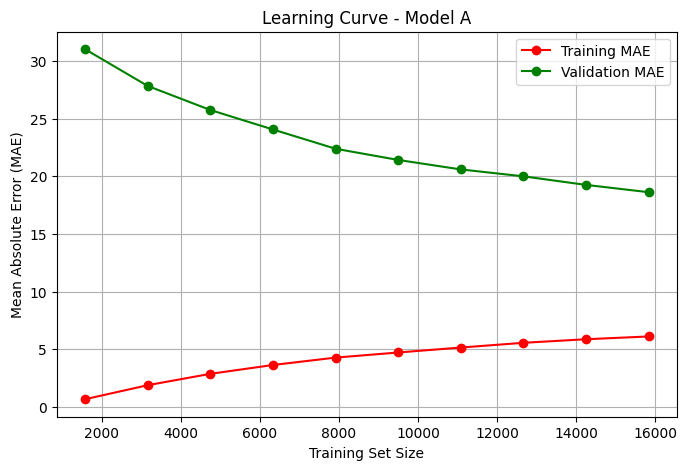

Model A GAP (final point): 12.521


In [ ]:
plot_LearningCurve(params_A, X_train, y_train, name="Model A")

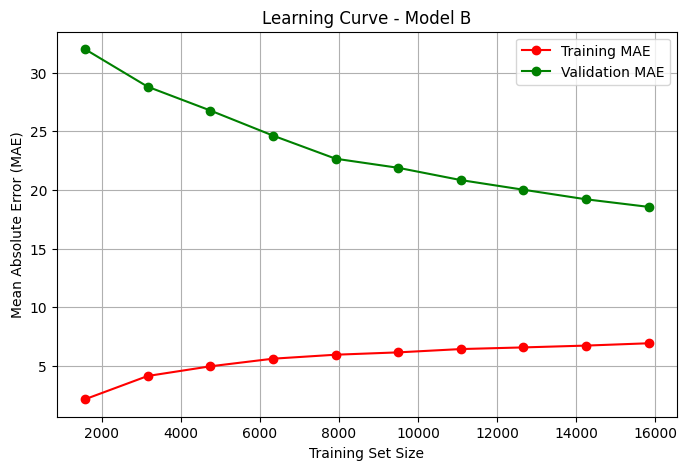

Model B GAP (final point): 11.636


In [ ]:
plot_LearningCurve(params_B, X_train, y_train, name="Model B")

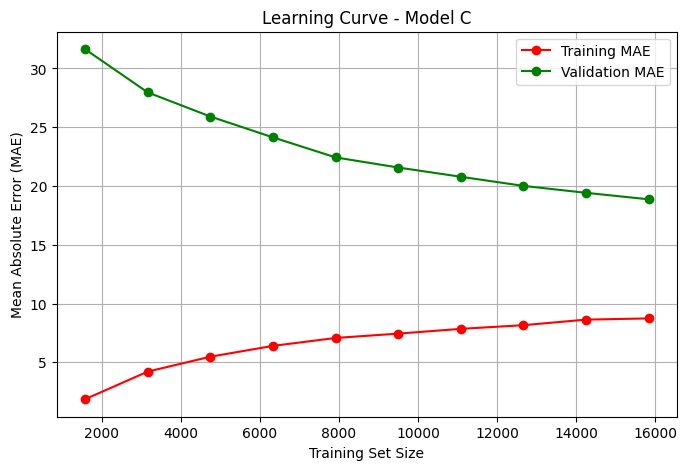

Model C GAP (final point): 10.132


In [ ]:
plot_LearningCurve(params_C, X_train, y_train, name="Model C")

Finally, the hyperparameters for C are selected because they have the lowest GAP, in order to avoid potential overfitting

## Final Model
Following a thorough analysis, it was decided to use the following features and hyperparameters for the Extreme Gradient Boost model

In [1]:
features_selected = [
                     'S_d',
                     'irradiation',
                      'fold_cos',
                      'panel_cos',
                      'altitude',
                      'azimuth_sin',
                      'azimuth_cos',
                      'hour_cos',
                      'month_sin',
                      'month_cos',
                      'day_year_sin',
                      'day_year_cos',
                      'DNI',
                      'GTI',
                      'is_day',
                      'month',
                      'day_year',
                      'hour'
                      ]



hyperparams = {
  'max_depth': 6,
 'learning_rate': 0.046409441595016,
 'n_estimators': 2250,
 'subsample': 0.9997873491049314,
 'colsample_bytree': 0.83393023157834,
 'min_child_weight': 5,
 'gamma': 0.046088138544593565,
 'reg_alpha': 1.696893413567287,
 'reg_lambda': 3.8856354962501007
  }



### Kaggle Solution

In [ ]:
Dataset_original_test = pd.read_csv("https://raw.githubusercontent.com/jfelipevasquez/Forecasting-electricity-production-Kaggle/refs/heads/main/dataset/test.csv").set_index('ID')
Dataset_original_test['start'] = pd.to_datetime(Dataset_original_test['start'], format='%d-%m-%y %H:%M')
Dataset_original_test['start'] = Dataset_original_test['start'].dt.strftime('%Y-%m-%d %H:%M:%S')

train = DataTransform(Dataset_original_train)
X_train = df[features_selected]

test = DataTransform(Dataset_original_test)
X_test = test[features_selected]

XGBoost = XGBRegressor(**hyperparams)

XGBoost.fit(X_train, y)

y_pred = XGBoost.predict(X_test)
y_pred[y_pred < 0] = 0

solution = X_test.index.to_frame()
solution['kw'] = y_pred
solution.to_csv('solution.csv', index=False)


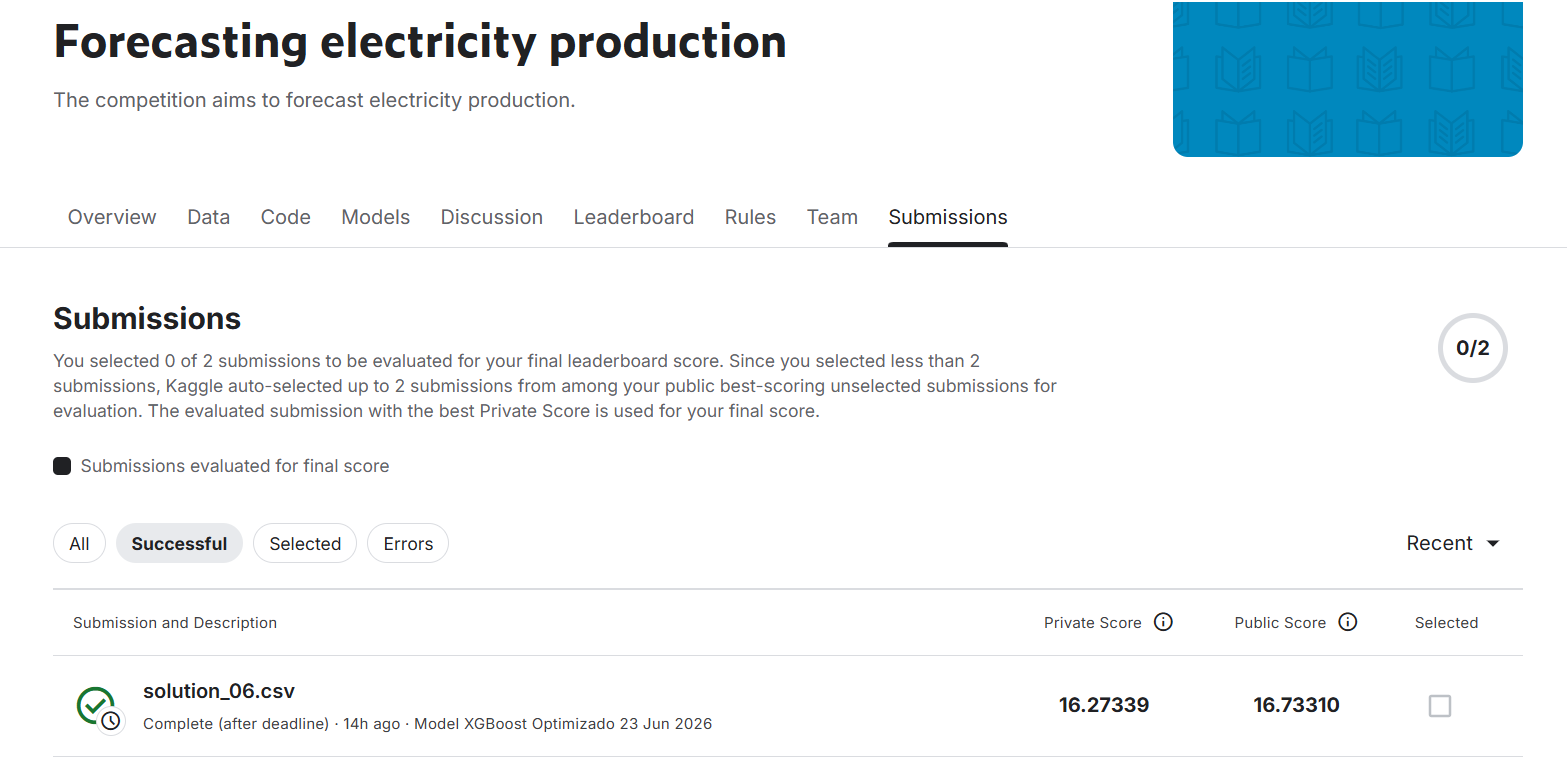